In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json

from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image

In [1]:
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

model = load_model(
    r"D:\Plant Disease Project\models\best_model.keras",
    custom_objects={"preprocess_input": preprocess_input}
)
print("model loaded successfully")


model loaded successfully


In [3]:
import json

with open(r"D:\Plant Disease Project\models\class_names.json", "r") as f:
    class_names = json.load(f)

print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

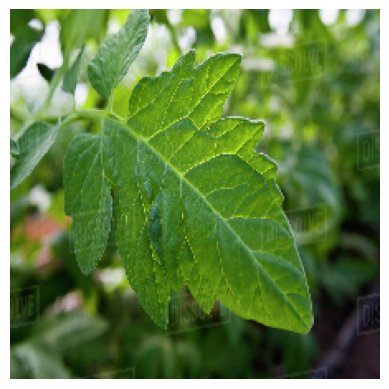

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 705ms/step
Top 5 Predictions:
Tomato___Late_blight : 96.41%
Squash___Powdery_mildew : 3.14%
Apple___Apple_scab : 0.13%
Pepper,_bell___healthy : 0.11%
Cherry_(including_sour)___Powdery_mildew : 0.11%


In [41]:
img_path = r"D:\Plant Disease Project\Test_images\tomato_healthy.jpg"

# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert image to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)


# Predict
prediction = model.predict(img_array)[0]

# Top 5 predictions
top5 = np.argsort(prediction)[-5:][::-1]

print("Top 5 Predictions:")
for i in top5:
    print(f"{class_names[i]} : {prediction[i]*100:.2f}%")